In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0106.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0375.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0285.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0074.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0077.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0498.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0426.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0235.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0273.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0307.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0444.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0058.jpg
/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/hail/0255.jpg
/kaggle/input/datasets/je

# Weather Image Recognition — CNN from Scratch vs. Transfer Learning

**Dataset:** [Weather Dataset (Kaggle)](https://www.kaggle.com/datasets/jehanbhathena/weather-dataset) — 11 weather classes:
`dew, fogsmog, frost, glaze, hail, lightning, rain, rainbow, rime, sandstorm, snow`

**Goal:** classify a photo into one of 11 weather conditions. Compare a from-scratch CNN baseline
against a fine-tuned MobileNetV2 transfer-learning model, with class-imbalance handling,
augmentation, per-class F1 / confusion matrix evaluation, and Grad-CAM explainability.

**How to run:** In Kaggle, click *Add Data* → search "Weather Dataset" (jehanbhathena/weather-dataset) → Add.
Then Run All. Everything below assumes the dataset lands at
`/kaggle/input/weather-dataset/dataset` (Kaggle's default extraction path for this dataset —
the cell in Section 1 auto-detects the actual folder name just in case it differs).


## 0. Setup & Imports

## 1. Locate & Inventory the Data

The Kaggle dataset ships as one folder per class (e.g. `dew/`, `fogsmog/`, `rain/`, ...).
We auto-detect the base folder so the notebook still works if Kaggle changes the exact
mount path, then build a single dataframe of `filepath, label` for every image.

In [2]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Locate dataset base directory
dataset_dir = "/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset"

# Fallback: find it dynamically if path changes slightly
if not os.path.exists(dataset_dir):
    for root, dirs, files in os.walk("/kaggle/input"):
        if "hail" in dirs:
            dataset_dir = root
            break

# 2. Collect image paths and class labels
filepaths = []
labels = []

valid_extensions = ('.jpg', '.jpeg', '.png')
classes = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]

for class_name in sorted(classes):
    class_folder = os.path.join(dataset_dir, class_name)
    for fname in os.listdir(class_folder):
        if fname.lower().endswith(valid_extensions):
            filepaths.append(os.path.join(class_folder, fname))
            labels.append(class_name)

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print(f"Total images found: {len(df)} across {len(classes)} classes: {classes}")

# 3. First split: 80% Train+Val pool, 20% Test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

# 4. Second split: 80% Train, 20% Val (from the 80% pool -> 64% / 16% of total)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    stratify=train_val_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 5. Display split counts
print(f"\nTrain images (64%): {len(train_df)}")
print(f"Val images   (16%): {len(val_df)}")
print(f"Test images  (20%): {len(test_df)}")


Total images found: 6862 across 11 classes: ['hail', 'rainbow', 'frost', 'rime', 'fogsmog', 'snow', 'rain', 'glaze', 'lightning', 'sandstorm', 'dew']

Train images (64%): 4391
Val images   (16%): 1098
Test images  (20%): 1373


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(classes)

# 1. Data Generators with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4391 validated image filenames belonging to 11 classes.
Found 1098 validated image filenames belonging to 11 classes.


In [5]:
# 2. Balanced Class Weights (handling 11-class variation)
unique_labels = np.unique(train_df["label"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_labels,
    y=train_df["label"]
)
class_weight_dict = {
    train_gen.class_indices[lbl]: w for lbl, w in zip(unique_labels, weights)
}

In [6]:
# 3. Model Architecture with Regularization
base_model = tf.keras.applications.DenseNet121(
    weights=None,           # Trains from scratch without downloading
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = True  # Train all layers since weights are randomized 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(
        256, 
        activation="relu", 
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Use modest initial learning rate to prevent early oscillation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3_acc")]
)

I0000 00:00:1789404101.691303      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789404101.694256      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
# 4. Anti-Overfitting Callbacks
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_weather_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [8]:
# 5. Train Head
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1789404278.475572     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3191 - loss: 2.2547 - top_3_acc: 0.6201
Epoch 1: val_loss improved from None to 2.51491, saving model to best_weather_model.keras

Epoch 1: finished saving model to best_weather_model.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - accuracy: 0.3853 - loss: 1.9993 - top_3_acc: 0.6980 - val_accuracy: 0.0811 - val_loss: 2.5149 - val_top_3_acc: 0.2923 - learning_rate: 2.0000e-04
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.4821 - loss: 1.7084 - top_3_acc: 0.7795
Epoch 2: val_loss did not improve from 2.51491
138/138 ━━━━━━━━━━━━━━━━━━━━ 67s 483ms/step - accuracy: 0.4846 - loss: 1.6978 - top_3_acc: 0.7830 - val_accuracy: 0.1248 - val_loss: 7.0955 - val_top_3_acc: 0.2896 - learning_rate: 2.0000e-04
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.5173 - loss: 1.5195 - top_3_acc: 0.8243
Epoch 3: ReduceLROnPlateau reducing learning rate to 5.999999848427251e-05.

Epoch 3: val_loss did not improve 

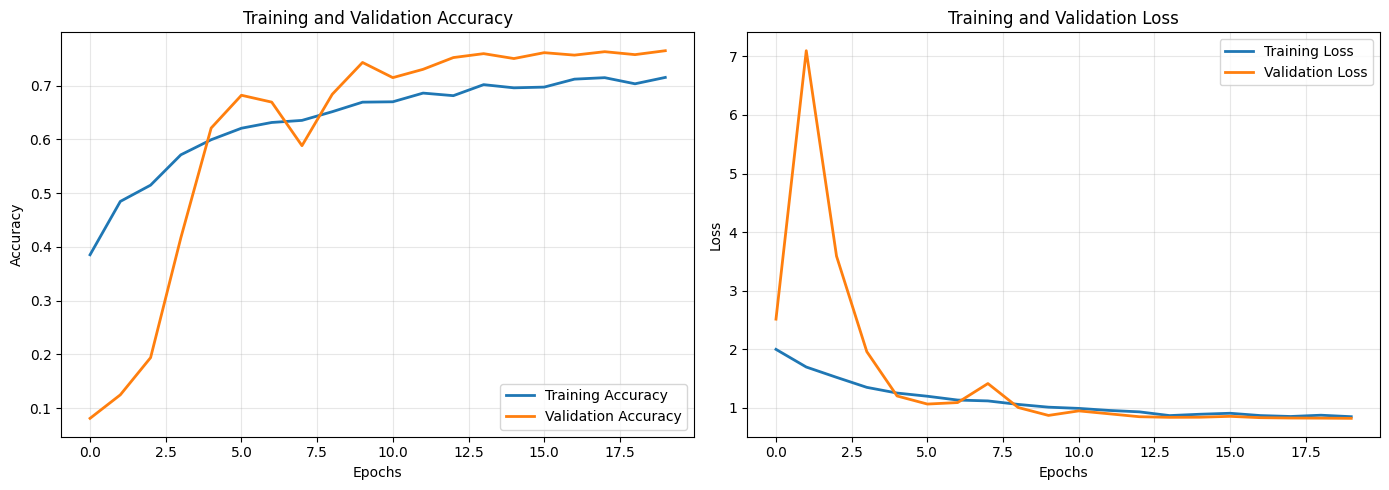

In [9]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:

# Create Test Data Generator (shuffle must be False)
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Evaluate model performance
test_results = model.evaluate(test_gen, verbose=1)
print(f"\nTest Loss:     {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1] * 100:.2f}%")
print(f"Test Top-3 Acc:{test_results[2] * 100:.2f}%")

Found 1373 validated image filenames belonging to 11 classes.
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 599ms/step - accuracy: 0.7684 - loss: 0.8110 - top_3_acc: 0.9410

Test Loss:     0.8110
Test Accuracy: 76.84%
Test Top-3 Acc:94.10%


43/43 ━━━━━━━━━━━━━━━━━━━━ 27s 379ms/step

Classification Report:

              precision    recall  f1-score   support

         dew       0.93      0.74      0.83       140
     fogsmog       0.83      0.86      0.84       170
       frost       0.52      0.67      0.58        95
       glaze       0.67      0.53      0.59       128
        hail       0.88      0.77      0.82       118
   lightning       0.80      0.93      0.86        76
        rain       0.70      0.77      0.73       105
     rainbow       0.71      0.76      0.74        46
        rime       0.80      0.87      0.84       232
   sandstorm       0.96      0.76      0.85       139
        snow       0.61      0.69      0.65       124

    accuracy                           0.77      1373
   macro avg       0.77      0.76      0.76      1373
weighted avg       0.78      0.77      0.77      1373



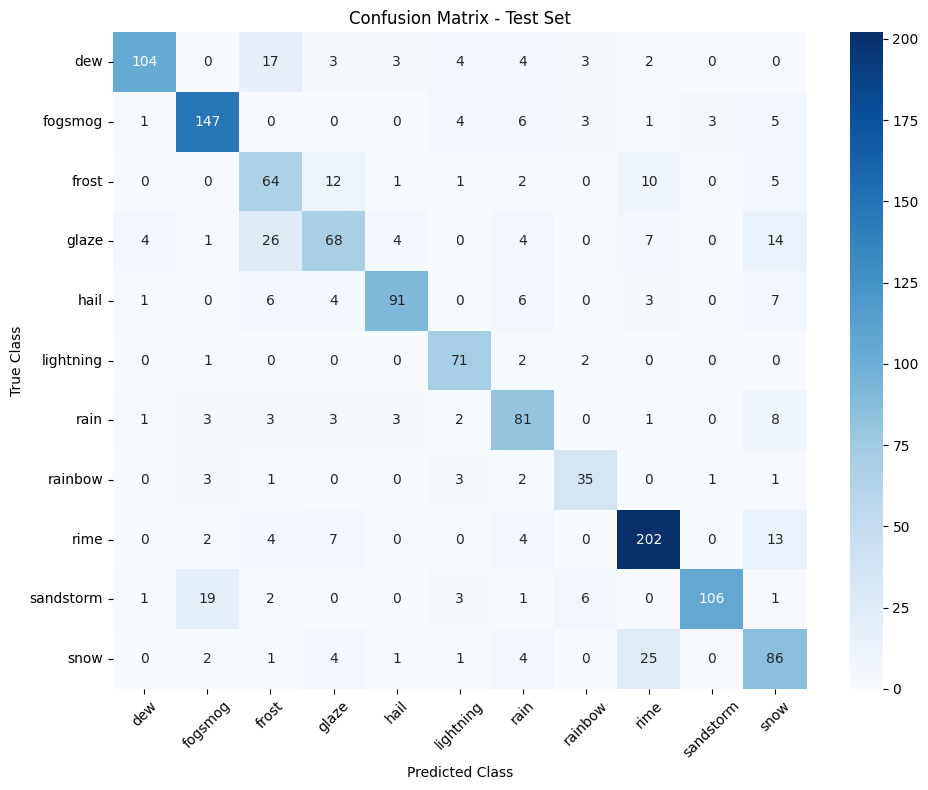

In [11]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get true and predicted labels
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Map label indices back to string class names
class_labels = list(test_gen.class_indices.keys())

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Unfreeze top layers of the backbone
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a very small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3, name="top_3_acc")]
)

# Continue training for a few more epochs
fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.7274 - loss: 0.7922 - top_3_acc: 0.9401
Epoch 1: val_loss improved from 0.82213 to 0.80039, saving model to best_weather_model.keras

Epoch 1: finished saving model to best_weather_model.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 133s 735ms/step - accuracy: 0.7235 - loss: 0.8120 - top_3_acc: 0.9358 - val_accuracy: 0.7668 - val_loss: 0.8004 - val_top_3_acc: 0.9362 - learning_rate: 1.0000e-05
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.7219 - loss: 0.7951 - top_3_acc: 0.9403
Epoch 2: val_loss did not improve from 0.80039
138/138 ━━━━━━━━━━━━━━━━━━━━ 66s 476ms/step - accuracy: 0.7247 - loss: 0.7944 - top_3_acc: 0.9383 - val_accuracy: 0.7668 - val_loss: 0.8027 - val_top_3_acc: 0.9344 - learning_rate: 1.0000e-05
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.7361 - loss: 0.7945 - top_3_acc: 0.9392
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_

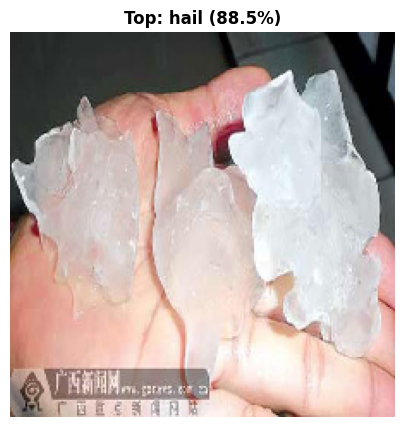

Top Predictions:
 - hail: 88.51%
 - rain: 6.30%
 - snow: 2.35%


In [13]:
from tensorflow.keras.preprocessing import image

# Create the mapping directly without needing generators
unique_classes = sorted(train_df["label"].unique())
idx_to_class = {i: cls for i, cls in enumerate(unique_classes)}

def predict_single_image(img_path, model, top_k=3):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    
    preds = model.predict(img_batch, verbose=0)[0]
    top_indices = np.argsort(preds)[::-1][:top_k]
    
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    title_text = f"Top: {idx_to_class[top_indices[0]]} ({preds[top_indices[0]]*100:.1f}%)"
    plt.title(title_text, fontsize=12, fontweight="bold")
    plt.show()
    
    print("Top Predictions:")
    for idx in top_indices:
        print(f" - {idx_to_class[idx]}: {preds[idx]*100:.2f}%")

# Test on a random image from the test set
sample_path = test_df.sample(1)["filepath"].values[0]
predict_single_image(sample_path, model)

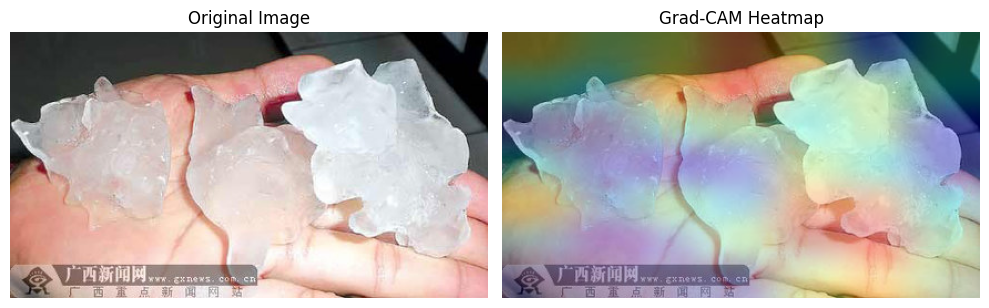

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def make_gradcam_heatmap(img_array, full_model, last_conv_layer_name="relu", pred_index=None):
    # 1. Access the DenseNet backbone (first layer in the Sequential model)
    backbone = full_model.layers[0]
    
    # Feature extractor mapping input image -> target conv layer activations
    grad_model = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=backbone.get_layer(last_conv_layer_name).output
    )

    # 2. Record operations with GradientTape
    with tf.GradientTape() as tape:
        # Get conv feature maps
        conv_outputs = grad_model(img_array)
        tape.watch(conv_outputs)
        
        # Pass features through the rest of the model layers
        x = conv_outputs
        # If backbone has remaining layers after the conv layer, pass through them
        # (In DenseNet121, 'relu' is the very last layer of the backbone)
        for layer in full_model.layers[1:]:
            x = layer(x)
            
        preds = x
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Compute gradients of the predicted class w.r.t. conv outputs
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 4. Weight conv channels by importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = image.load_img(img_path)
    img = image.img_to_array(img)

    # Rescale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Apply 'jet' colormap
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to original image dimensions
    jet_heatmap = image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = image.img_to_array(jet_heatmap)

    # Superimpose heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = image.array_to_img(superimposed_img)

    # Display plots
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image.load_img(img_path))
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(superimposed_img)
    ax[1].set_title("Grad-CAM Heatmap")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

# Run Grad-CAM using the complete trained model
img = image.load_img(sample_path, target_size=IMG_SIZE)
img_array = np.expand_dims(image.img_to_array(img) / 255.0, axis=0)

# Pass the full 'model' (not base_model)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="relu")
display_gradcam(sample_path, heatmap)

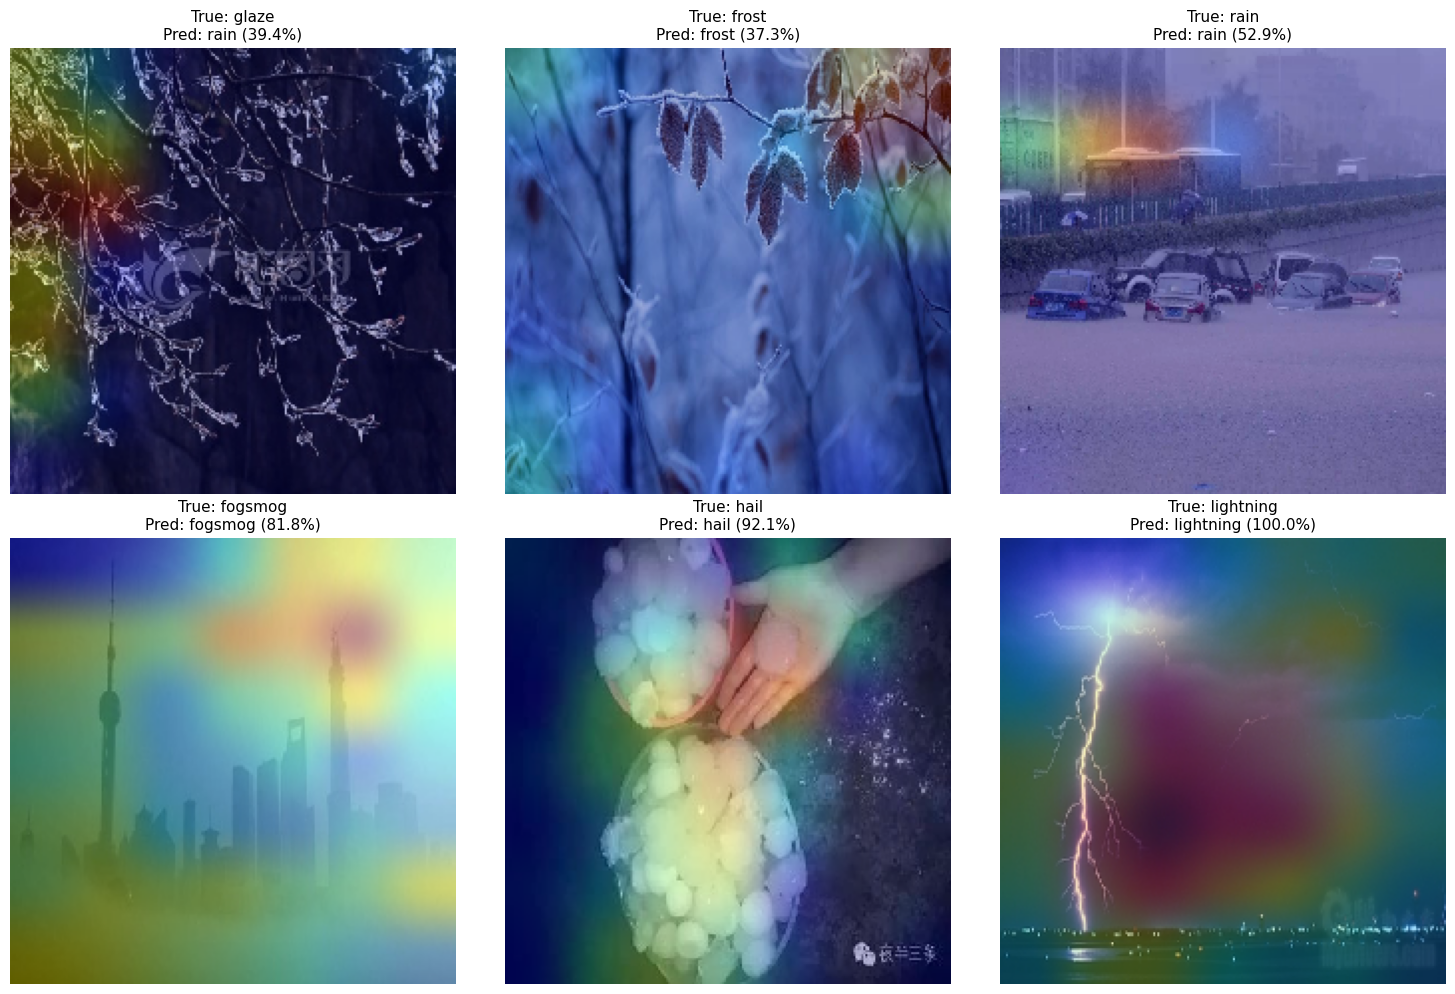

In [16]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Select 6 distinct classes present in test_df
selected_classes = list(test_df['label'].unique())[:6]
sample_images = [test_df[test_df['label'] == cls].iloc[0]['filepath'] for cls in selected_classes]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, img_path in enumerate(sample_images):
    # Load and process image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = np.expand_dims(image.img_to_array(img) / 255.0, axis=0)
    
    # Prediction
    preds = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_class = idx_to_class[pred_idx]
    confidence = preds[pred_idx] * 100
    true_class = test_df[test_df['filepath'] == img_path]['label'].values[0]
    
    # Compute heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="relu")
    heatmap = np.uint8(255 * heatmap)
    
    # Superimpose heatmap
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = image.array_to_img(jet_colors[heatmap])
    jet_heatmap = jet_heatmap.resize((img.size[0], img.size[1]))
    jet_heatmap = image.img_to_array(jet_heatmap)
    
    superimposed = jet_heatmap * 0.4 + image.img_to_array(img)
    superimposed = image.array_to_img(superimposed)
    
    axes[i].imshow(superimposed)
    axes[i].set_title(f"True: {true_class}\nPred: {pred_class} ({confidence:.1f}%)", fontsize=11)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Found 1373 validated image filenames belonging to 11 classes.
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 414ms/step

Classification Report:

              precision    recall  f1-score   support

         dew       0.92      0.75      0.83       140
     fogsmog       0.84      0.82      0.83       170
       frost       0.50      0.69      0.58        95
       glaze       0.70      0.53      0.60       128
        hail       0.88      0.76      0.82       118
   lightning       0.79      0.93      0.86        76
        rain       0.68      0.79      0.73       105
     rainbow       0.69      0.76      0.72        46
        rime       0.82      0.85      0.84       232
   sandstorm       0.94      0.76      0.84       139
        snow       0.62      0.73      0.67       124

    accuracy                           0.77      1373
   macro avg       0.76      0.76      0.76      1373
weighted avg       0.78      0.77      0.77      1373



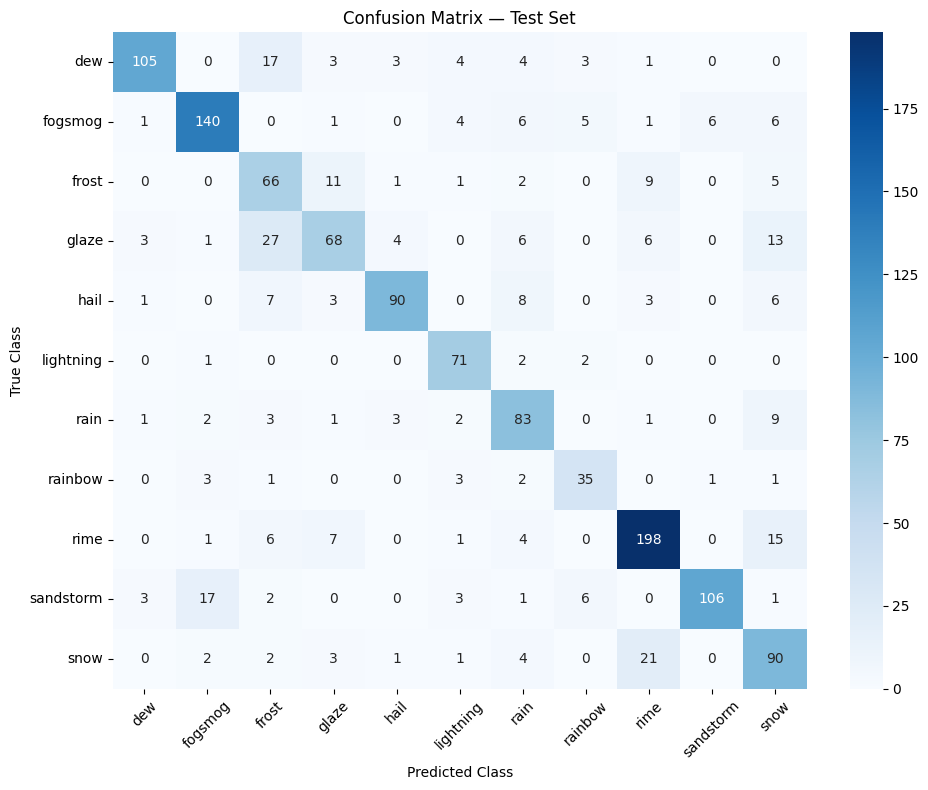

In [17]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Initialize test generator
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Predict full test set
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Text Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
import json

# 1. Save full model
model.save("best_weather_model.keras")

# 2. Save class labels mapping
with open("weather_classes.json", "w") as f:
    json.dump(idx_to_class, f)

print("Saved best_weather_model.keras and weather_classes.json in /kaggle/working/")

Saved best_weather_model.keras and weather_classes.json in /kaggle/working/
